# Loading Experiment Data Tutorial

This notebook demonstrates how to load and analyze experiment data logged by the BeamNG ROS2 simulator framework.

## Overview

The logging system creates run folders with the following structure:
```
~/beamng_log_data/
├── run_001/
│   ├── metadata.yaml          # Run configuration and metadata
│   ├── data/
│   │   └── data.pkl           # Consolidated sensor data (custom polling)
│   └── rosbag_YYYYMMDD_HHMMSS/
│       ├── metadata.yaml      # Rosbag metadata
│       └── *.mcap             # ROS2 message data
```

This tutorial covers:
1. Loading run metadata
2. Loading consolidated pickle data (custom sensors)
3. Loading rosbag/MCAP data (ROS topics)
4. Using the unified `load_run_data()` function
5. Analyzing and visualizing the data

In [1]:
import sys
from pathlib import Path

# Add the bng_simulator module to the path if needed
# sys.path.insert(0, str(Path.cwd().parent / "bng_simulator"))

from bng_simulator.utils.logger_utils import (
    load_metadata,
    load_consolidated_data,
    load_run_data,
)

import numpy as np
import matplotlib.pyplot as plt

# Pretty printing
from pprint import pprint

print("✓ Imports successful")

✓ Imports successful


In [2]:
mcap_file = Path("~/beamng_log_data/run_002/rosbag_20260127_164024/rosbag_20260127_164024_0.mcap").expanduser()
print(f"MCAP file exists: {mcap_file.exists()}")
print(f"MCAP file size: {mcap_file.stat().st_size / 1024:.2f} KB")

# Try opening with rosbag2_py directly
try:
    from rosbag2_py import SequentialReader, StorageOptions, ConverterOptions
    
    reader = SequentialReader()
    storage_options = StorageOptions(
        uri=str(mcap_file.parent), 
        storage_id="mcap"
    )
    converter_options = ConverterOptions(
        input_serialization_format="cdr",
        output_serialization_format="cdr"
    )
    
    reader.open(storage_options, converter_options)
    
    # Check what topics the reader sees
    topics = reader.get_all_topics_and_types()
    print(f"\nTopics found by reader: {len(topics)}")
    for t in topics:
        print(f"  {t.name}: {t.type}")
    
    # Try to read messages
    msg_count = 0
    while reader.has_next() and msg_count < 10:
        topic, data, timestamp = reader.read_next()
        print(f"Message {msg_count}: topic={topic}, timestamp={timestamp}, size={len(data)} bytes")
        msg_count += 1
    
    print(f"\nTotal messages read: {msg_count}")
    
except Exception as e:
    print(f"Error reading MCAP: {e}")
    import traceback
    traceback.print_exc()

MCAP file exists: True
MCAP file size: 1888.81 KB

Topics found by reader: 6
  /parameter_events: rcl_interfaces/msg/ParameterEvent
  /EGO/gtstate: bng_msgs/msg/GtStateMsg
  /EGO/basicState: bng_msgs/msg/BasicStateMsg
  /events/write_split: rosbag2_interfaces/msg/WriteSplitEvent
  /EGO/reduced_state: bng_msgs/msg/ReducedGtStateMsg
  /rosout: rcl_interfaces/msg/Log
Message 0: topic=/rosout, timestamp=1769550029379138837, size=148 bytes
Message 1: topic=/rosout, timestamp=1769550029379147620, size=128 bytes
Message 2: topic=/rosout, timestamp=1769550029379148744, size=160 bytes
Message 3: topic=/rosout, timestamp=1769550029379411241, size=144 bytes
Message 4: topic=/rosout, timestamp=1769550029381507307, size=156 bytes
Message 5: topic=/rosout, timestamp=1769550029381655025, size=120 bytes
Message 6: topic=/rosout, timestamp=1769550029488953783, size=212 bytes
Message 7: topic=/rosout, timestamp=1769550029493504460, size=152 bytes
Message 8: topic=/rosout, timestamp=1769550029494878951, 

In [ ]:
# Load metadata for run_001
run_number = 2

try:
    metadata = load_metadata(run_number, root_dir="~/beamng_log_data")
    print("Run metadata:")
    pprint(metadata)
except FileNotFoundError as e:
    print(f"❌ Run {run_number:03d} not found. Make sure you have logged data!")
    print(f"   Error: {e}")

In [ ]:
vehicle_name = "EGO"
try:
    pickle_data = load_consolidated_data(run_number, root_dir="~/beamng_log_data")
    
    print(f"Available data keys: {list(pickle_data.keys())}\n")
    pickle_data = pickle_data["data"]
    # Example: Extract ego vehicle gtstate data
    if (vehicle_name, "gtstate") in pickle_data:
        gtstate = pickle_data[(vehicle_name, "gtstate")]
        print(f"gtstate fields: {list(gtstate.keys())}")
        print(f"\nSample data lengths: (there are more)")
        for key in list(gtstate.keys())[:15]:
            if isinstance(gtstate[key], list):
                print(f"  {key}: {len(gtstate[key])} samples")
    else:
        print("No (ego, gtstate) data found in this run")
        
except FileNotFoundError as e:
    print(f"❌ Data file not found: {e}")

In [ ]:
run_number = 2
try:
    # Load everything: pickle + rosbag
    all_data = load_run_data(
        run_number=run_number,
        root_dir="~/beamng_log_data",
        include_pickle=True,
        include_rosbag=True,
        decode_rosbag_messages=True,
        max_rosbag_messages_per_topic=10000,  # Limit per topic to avoid memory issues
        rosbag_pick="latest"  # or "first" if multiple rosbags exist
    )
    
    print(f"Total data sources loaded: {len(all_data)}\n")
    print("Available keys:")
    for key in all_data.keys():
        print(f"  {key}: data keys = {len(all_data[key])}")
            
except FileNotFoundError as e:
    print(f"❌ {e}")
except RuntimeError as e:
    print(f"⚠️ {e}")
    print("   Rosbag loading requires ROS2 Python packages (rosbag2_py, rclpy)")
    print("   Falling back to pickle-only mode...")
    
    # Fallback: load only pickle data
    all_data = load_run_data(
        run_number=run_number,
        root_dir="~/beamng_log_data",
        include_pickle=True,
        include_rosbag=False
    )

Total data sources loaded: 6

Available keys:
  EGO/basicState: data keys = 20
  EGO/gtstate: data keys = 94
  /rosout: data keys = 10
  /EGO/reduced_state: data keys = 23
  /EGO/basicState: data keys = 22
  /EGO/gtstate: data keys = 100


In [7]:
# Check if we have rosbag data
rosbag_topics = [k for k in all_data.keys() if isinstance(k, str) and k.startswith("/")]

if rosbag_topics:
    print(f"Found {len(rosbag_topics)} rosbag topic(s):\n")
    
    for topic in rosbag_topics:
        data = all_data[topic]
        print(f"{topic}:")
        print(f"  Message type: {data.get('type')}")
        print(f"  Message count: {len(data.get('messages', []))}")
        print(f"  Timestamp range: {data['timestamps_ns'][0]} - {data['timestamps_ns'][-1]} ns")
        
        # Show structure of first message
        print(f"  Message fields: {list(data.keys())[:10]}...")
else:
    print("No rosbag topics loaded (may require ROS2 runtime or no rosbag in this run)")

Found 4 rosbag topic(s):

/rosout:
  Message type: rcl_interfaces/msg/Log
  Message count: 0
  Timestamp range: 1769550029379138837 - 1769550103783051753 ns
  Message fields: ['type', 'timestamps_ns', 'stamp_sec', 'stamp_nanosec', 'level', 'name', 'msg', 'file', 'function', 'line']...
/EGO/reduced_state:
  Message type: bng_msgs/msg/ReducedGtStateMsg
  Message count: 0
  Timestamp range: 1769550029500800211 - 1769550079419233008 ns
  Message fields: ['type', 'timestamps_ns', 'header_stamp_sec', 'header_stamp_nanosec', 'header_frame_id', 'time', 'x', 'y', 'yaw', 'vel_mag']...
/EGO/basicState:
  Message type: bng_msgs/msg/BasicStateMsg
  Message count: 0
  Timestamp range: 1769550029538904861 - 1769550103830396744 ns
  Message fields: ['type', 'timestamps_ns', 'header_stamp_sec', 'header_stamp_nanosec', 'header_frame_id', 'time', 'position_x', 'position_y', 'position_z', 'direction_x']...
/EGO/gtstate:
  Message type: bng_msgs/msg/GtStateMsg
  Message count: 0
  Timestamp range: 17695500

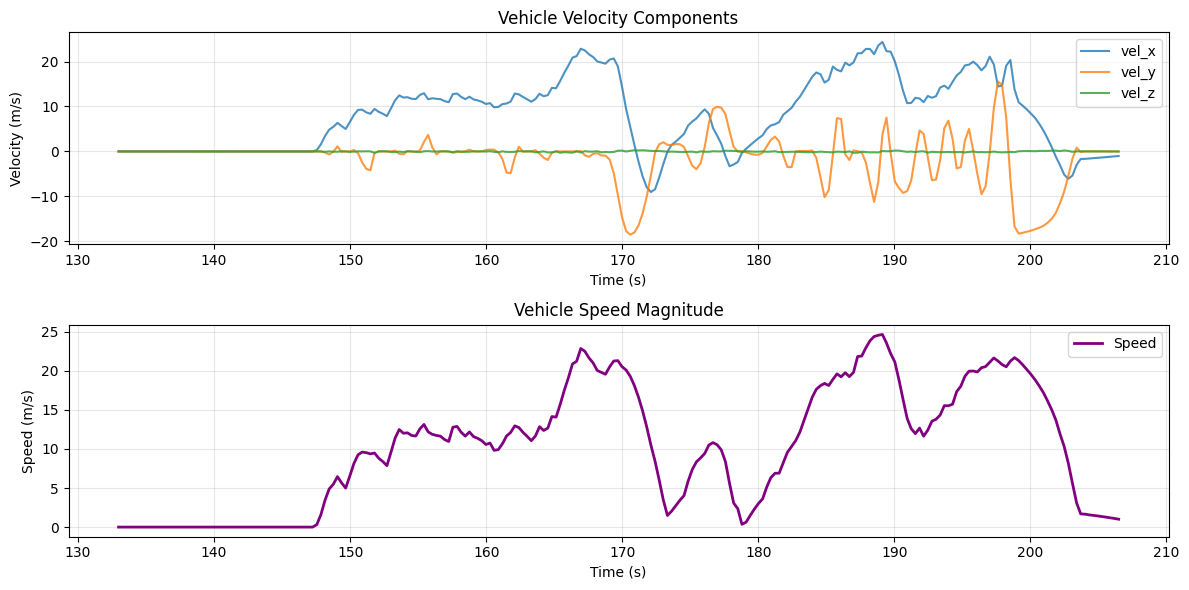

Mean speed: 10.35 m/s
Max speed: 24.64 m/s


In [10]:
if "/EGO/gtstate" in all_data:
    gtstate = all_data["/EGO/gtstate"]
    
    # Extract time and velocity data
    time = np.array(gtstate.get("time", []))
    vel_x = np.array(gtstate.get("vel_x", []))
    vel_y = np.array(gtstate.get("vel_y", []))
    vel_z = np.array(gtstate.get("vel_z", []))
    
    # Compute speed magnitude
    speed = np.sqrt(vel_x**2 + vel_y**2 + vel_z**2)
    
    # Plot
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(time, vel_x, label="vel_x", alpha=0.8)
    plt.plot(time, vel_y, label="vel_y", alpha=0.8)
    plt.plot(time, vel_z, label="vel_z", alpha=0.8)
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (m/s)")
    plt.title("Vehicle Velocity Components")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.plot(time, speed, label="Speed", color="purple", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Speed (m/s)")
    plt.title("Vehicle Speed Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Mean speed: {speed.mean():.2f} m/s")
    print(f"Max speed: {speed.max():.2f} m/s")
else:
    print("No gtstate data available for plotting")

In [ ]:
pickle_key = ("ego", "gtstate")
rosbag_key = "/ego/gtstate"

has_pickle = pickle_key in all_data
has_rosbag = rosbag_key in all_data

print(f"Pickle data available: {has_pickle}")
print(f"Rosbag data available: {has_rosbag}\n")

if has_pickle and has_rosbag:
    pickle_data = all_data[pickle_key]
    rosbag_data = all_data[rosbag_key]
    
    pickle_samples = len(pickle_data.get("time", []))
    rosbag_samples = len(rosbag_data.get("messages", []))
    
    print(f"Pickle samples: {pickle_samples}")
    print(f"Rosbag samples: {rosbag_samples}")
    
    if pickle_samples > 0 and rosbag_samples > 0:
        pickle_duration = pickle_data["time"][-1] - pickle_data["time"][0]
        rosbag_duration = (rosbag_data["timestamps_ns"][-1] - rosbag_data["timestamps_ns"][0]) / 1e9
        
        print(f"\nPickle duration: {pickle_duration:.2f} s")
        print(f"Rosbag duration: {rosbag_duration:.2f} s")
        
        print(f"\nPickle sample rate: {pickle_samples / pickle_duration:.2f} Hz")
        print(f"Rosbag sample rate: {rosbag_samples / rosbag_duration:.2f} Hz")
elif has_pickle:
    pickle_samples = len(all_data[pickle_key].get("time", []))
    print(f"Only pickle data available with {pickle_samples} samples")
elif has_rosbag:
    rosbag_samples = len(all_data[rosbag_key].get("messages", []))
    print(f"Only rosbag data available with {rosbag_samples} samples")
else:
    print("No gtstate data found in either source")

In [ ]:
if ("ego", "gtstate") in all_data:
    gtstate = all_data[("ego", "gtstate")]
    
    # Check if control fields exist
    control_fields = ["throttle", "brake", "steering"]
    available_controls = [f for f in control_fields if f in gtstate]
    
    if available_controls:
        time = np.array(gtstate["time"])
        
        plt.figure(figsize=(12, 8))
        
        for i, field in enumerate(available_controls, 1):
            plt.subplot(len(available_controls), 1, i)
            data = np.array(gtstate[field])
            plt.plot(time, data, linewidth=1.5)
            plt.xlabel("Time (s)")
            plt.ylabel(field.capitalize())
            plt.title(f"{field.capitalize()} Input Over Time")
            plt.grid(True, alpha=0.3)
            plt.ylim([-0.1, 1.1] if field != "steering" else [None, None])
        
        plt.tight_layout()
        plt.show()
    else:
        print("No control input fields found (throttle, brake, steering)")
else:
    print("No gtstate data available")